<a href="https://colab.research.google.com/github/vaibhavm291/PROTOTYPES-/blob/main/GEM%2BDIS%20_INTEGRATION%20-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

%pip install rasterio geopandas

In [3]:
import rasterio
import geopandas as gpd
from shapely.geometry import shape

In [4]:
import rasterio
import matplotlib.pyplot as plt

In [5]:
import json
from google.colab.patches import cv2_imshow
from google.colab import files
uploaded = files.upload()

Saving P5_PAN_CD_N22_000_E082_000_DEM_30m.tif to P5_PAN_CD_N22_000_E082_000_DEM_30m.tif


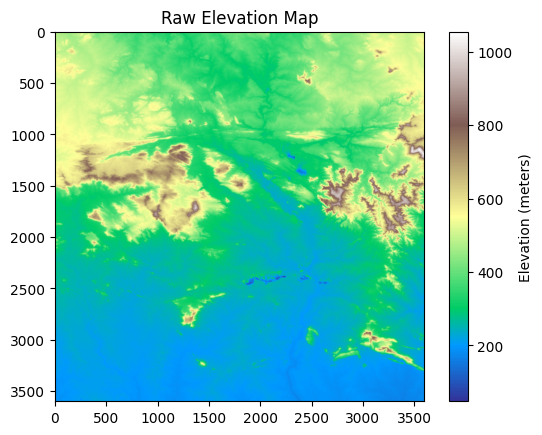

In [6]:
dem_path = 'P5_PAN_CD_N22_000_E082_000_DEM_30m.tif'

with rasterio.open(dem_path) as src:
    elevation = src.read(1)  # 2D numpy array
    transform = src.transform
    crs = src.crs

plt.imshow(elevation, cmap='terrain')
plt.colorbar(label='Elevation (meters)')
plt.title("Raw Elevation Map")
plt.show()


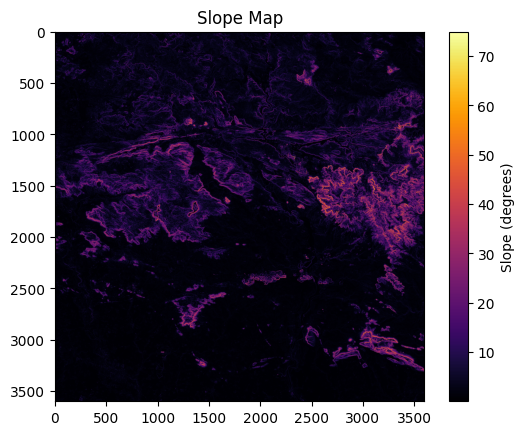

In [7]:
import numpy as np

def compute_slope(elevation, pixel_size):
    dzdx = np.gradient(elevation, axis=1) / pixel_size
    dzdy = np.gradient(elevation, axis=0) / pixel_size
    slope = np.sqrt(dzdx**2 + dzdy**2)
    return np.degrees(np.arctan(slope))

pixel_size = 30  # Adjust based on your .tif (often 30m resolution)
slope_map = compute_slope(elevation, pixel_size)

plt.imshow(slope_map, cmap='inferno')
plt.colorbar(label='Slope (degrees)')
plt.title("Slope Map")
plt.show()

In [8]:
# Create zone masks
pooling_zone = slope_map < 2      # Risk of water pooling 🟥
safe_zone    = (slope_map >= 2) & (slope_map <= 5)  # Good for construction 🟩
steep_zone   = slope_map > 10     # Too steep → needs retaining 🟨

# Create a visual map
risk_map = np.zeros_like(slope_map)

# Assign class IDs (just for color mapping later)
risk_map[pooling_zone] = 1   # 🟥
risk_map[safe_zone]    = 2   # 🟩
risk_map[steep_zone]   = 3   # 🟨

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127959 (\N{BUILDING CONSTRUCTION}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


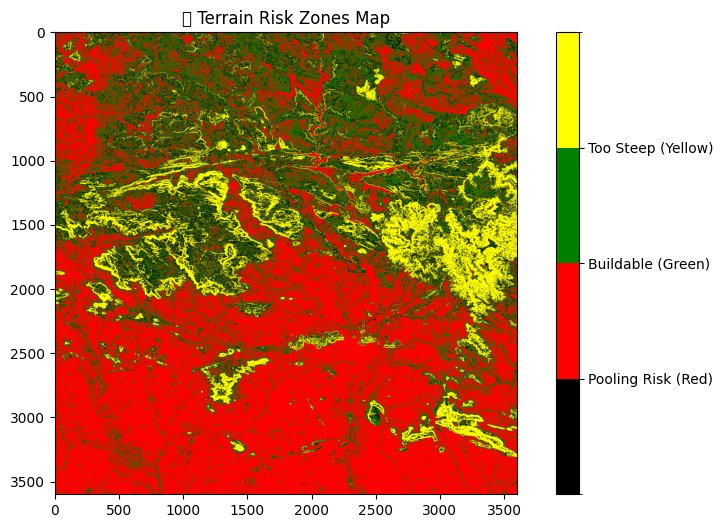

In [9]:

import matplotlib.colors as colors

# Define custom color map
cmap = colors.ListedColormap(['black', 'red', 'green', 'yellow'])
bounds = [0, 1, 2, 3, 4]
norm = colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
plt.imshow(risk_map, cmap=cmap, norm=norm)
plt.title("🏗️ Terrain Risk Zones Map")
plt.colorbar(ticks=[1, 2, 3], format=plt.FuncFormatter(lambda val, _: {1: "Pooling Risk (Red)", 2: "Buildable (Green)", 3: "Too Steep (Yellow)"}.get(val, '')))
plt.show()


In [10]:

from rasterio import Affine
from rasterio.transform import from_origin
import rasterio

In [11]:
# Open the DEM again to get metadata
with rasterio.open(dem_path) as src:
    profile = src.profile
    transform = src.transform
    crs = src.crs

# Update profile for the risk map
profile.update(
    dtype=rasterio.uint8,
    count=1,
    compress='lzw',
    nodata=None # Remove nodata value as it's not compatible with uint8
)

# Remove crs and transform from profile before unpacking
del profile['crs']
del profile['transform']


# Save risk map as GeoTIFF
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif", 'w', transform=transform, crs=crs, **profile) as dst:
    dst.write(risk_map.astype(rasterio.uint8), 1)

In [12]:
from rasterio.transform import from_origin

# Replace with real-world lat/lon of top-left corner
lon_top_left = 82.1234
lat_top_left = 22.5678

pixel_size = 30  # adjust if needed
transform = from_origin(lon_top_left, lat_top_left, pixel_size, pixel_size)

crs = 'EPSG:4326'  # WGS84


In [13]:
profile.update(transform=transform, crs=crs)


In [14]:

import numpy as np
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# Open the processed GeoTIFF
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    image = src.read(1)
    mask = image > 0  # only where slope exists
    results = (
        {"properties": {"risk": int(v)}, "geometry": shape(s)}
        for s, v in shapes(image, mask=mask, transform=src.transform)
    )

# Create GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(list(results), crs=src.crs)

# Save to GeoJSON
gdf.to_file("slope_risk.geojson", driver="GeoJSON")

In [15]:
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    image = src.read(1)
    mask = image > 0  # only where slope exists
    results = (
        {"properties": {"risk": int(v)}, "geometry": shape(s)}
        for s, v in shapes(image, mask=mask, transform=src.transform)
    )
gdf = gpd.GeoDataFrame.from_features(list(results), crs=src.crs)

In [16]:
import numpy as np
import rasterio
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape

# Open the processed GeoTIFF
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    image = src.read(1)
    mask = image > 0  # only where slope exists
    results = (
        {"properties": {"risk": int(v)}, "geometry": shape(s)}
        for s, v in shapes(image, mask=mask, transform=src.transform)
    )

# Create GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(list(results), crs=src.crs)

# Save to GeoJSON
gdf.to_file("slope_risk.geojson", driver="GeoJSON")



In [17]:
from rasterio.features import shapes
from shapely.geometry import shape

# Recreate results generator as it was likely consumed in a previous cell
results = (
    {"properties": {"risk": int(v)}, "geometry": shape(s)}
    for s, v in shapes(image, mask=mask, transform=transform)
)
gdf = gpd.GeoDataFrame.from_features(list(results), crs=crs)

In [18]:
if not gdf.empty:
    gdf.to_file("slope_risk.geojson", driver="GeoJSON")
else:
    print("⚠️ No features found — GeoJSON not saved.")


In [19]:
print(np.unique(risk_map))

[0. 1. 2. 3.]


In [20]:
from shapely.geometry import shape
from rasterio.features import shapes
import geopandas as gpd
import rasterio
import numpy as np

# Open the processed GeoTIFF
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    image = src.read(1)
    mask = image > 0  # only where slope exists
    transform = src.transform
    crs = src.crs

    # Extract polygons for non-zero areas
    results = (
        {"properties": {"risk": int(v)}, "geometry": shape(s)}
        for s, v in shapes(image.astype(np.uint8), mask=mask, transform=transform)
    )

# Create GeoDataFrame
results_list = list(results)

if results_list:
    gdf = gpd.GeoDataFrame.from_features(results_list, crs=crs)
    # Save it!
    gdf.to_file("slope_risk.geojson", driver="GeoJSON")
    print("GeoJSON file 'slope_risk.geojson' created successfully.")
else:
    print("⚠️ No features found — GeoJSON not saved.")


GeoJSON file 'slope_risk.geojson' created successfully.


<Axes: >

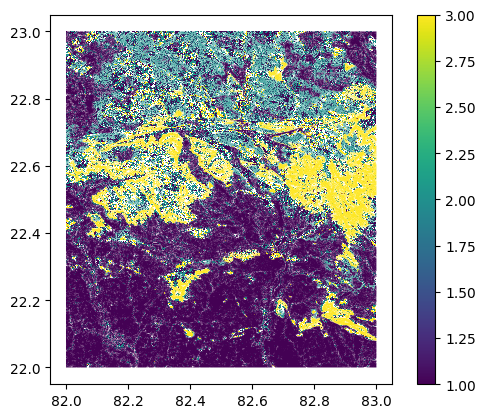

In [21]:
gdf.plot(column="risk", legend=True)

In [22]:
gdf.crs = crs

In [23]:
gdf.to_file("slope_risk.geojson", driver="GeoJSON")


In [24]:
gis = gpd.read_file("slope_risk.geojson")

In [25]:
gdf.crs = "EPSG:4326"  # WGS84 - lat/lon


In [26]:
gis = gis.to_crs(gdf.crs)


In [ ]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.geometry import shape

# --- Step 1: Load DEM ---
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    elevation = src.read(1)
    transform = src.transform

# --- Step 2: Compute Slope ---
def compute_slope(elevation, pixel_size):
    dzdx = np.gradient(elevation, axis=1) / pixel_size
    dzdy = np.gradient(elevation, axis=0) / pixel_size
    slope = np.sqrt(dzdx**2 + dzdy**2)
    return np.degrees(np.arctan(slope))

slope = compute_slope(elevation, pixel_size=30)

# --- Step 3: Classify Risk Zones (low slope = pooling) ---
risk = np.zeros_like(slope)
risk[slope < 2] = 1  # High pooling risk
risk[slope > 10] = 2  # Too steep
risk[(slope >= 2) & (slope <= 5)] = 3  # Ideal

# --- Step 4: Convert Risk Map to GeoDataFrame ---
rows, cols = np.where(risk > 0)
xs, ys = rasterio.transform.xy(transform, rows, cols)
geoms = [box(x-15, y-15, x+15, y+15) for x, y in zip(xs, ys)]  # 30m pixel
gdf = gpd.GeoDataFrame({'risk': risk[rows, cols]}, geometry=geoms, crs="EPSG:4326")

# 🧹 Optional: Simplify geometries to speed up
gdf["geometry"] = gdf["geometry"].simplify(0.0005)

# --- Step 5: Load GIS Civic Infra Layer (roads, drains) ---
gis = gpd.read_file("slope_risk.geojson")
gis = gis.to_crs(gdf.crs)

# --- Step 6: Spatial Join (MUCH faster than overlay) ---
joined = gpd.sjoin(gdf, gis, how="inner", predicate="intersects")

# --- Step 7: Plot and Done! ---
gdf.plot(column="risk", cmap="viridis", legend=True)
plt.title("Risk Zones from DEM")
plt.show()

joined.plot()
plt.title("Zones Intersecting Civic Infra")
plt.show()




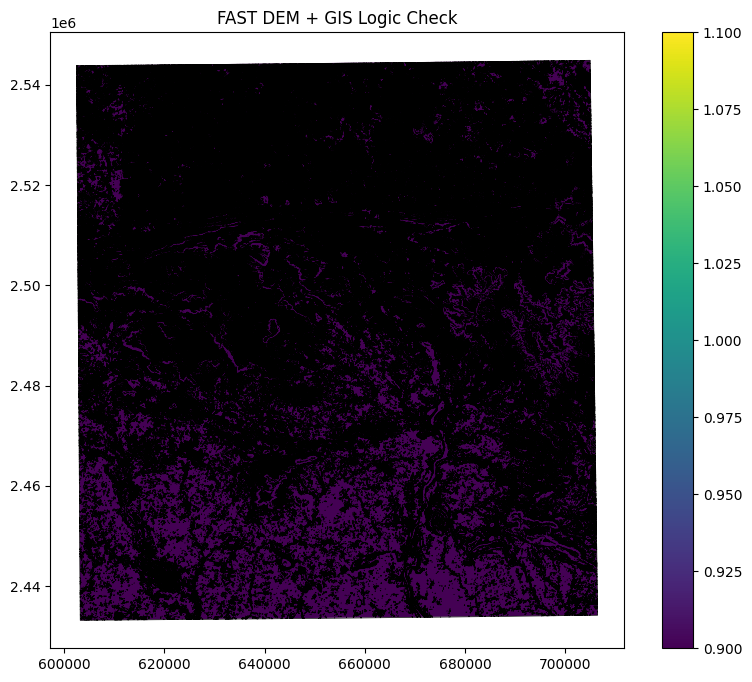

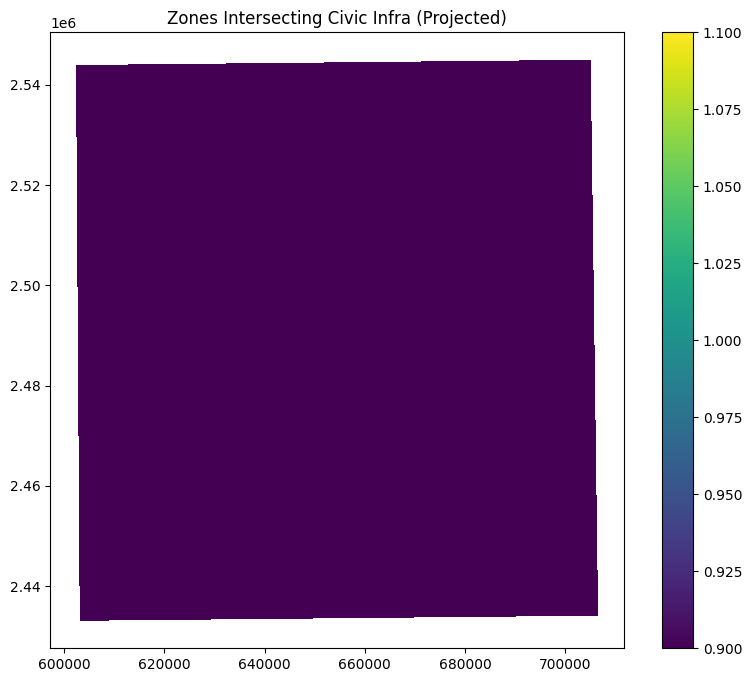

In [4]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.features import shapes

# --- Step 1: Load DEM ---
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    elevation = src.read(1)
    transform = src.transform
    crs = src.crs # This will be EPSG:4326 from previous cells

# ⭐ FAST MODE (Downsample DEM)
factor = 5   # increase → faster but less detailed
elevation = elevation[::factor, ::factor]

# Adjust transform for new resolution
transform = transform * rasterio.Affine.scale(factor, factor)

# --- Step 2: Compute Slope ---
def compute_slope(elevation, pixel_size):
    dzdx = np.gradient(elevation, axis=1) / pixel_size
    dzdy = np.gradient(elevation, axis=0) / pixel_size
    slope = np.sqrt(dzdx**2 + dzdy**2)
    return np.degrees(np.arctan(slope))

slope = compute_slope(elevation, pixel_size=30 * factor)

# --- Step 3: Classify Risk ---
risk = np.zeros_like(slope, dtype=np.int16)
risk[slope < 2] = 1
risk[slope > 10] = 2
risk[(slope >= 2) & (slope <= 5)] = 3

# --- Step 4: Raster → Vector (FAST) ---
mask = risk > 0

results = (
    {"properties": {"risk": int(v)}, "geometry": s}
    for s, v in shapes(risk, mask=mask, transform=transform)
)

gdf = gpd.GeoDataFrame.from_features(list(results), crs=crs)

# --- Reproject to a projected CRS for accurate area calculation and spatial operations ---
# For ~22N, 82E, UTM Zone 44N (EPSG:32644) is suitable
projected_crs = "EPSG:32644"
gdf_proj = gdf.to_crs(projected_crs)

# ⭐ Extra speed boost: Apply filter on projected data where area is in meaningful units (e.g., meters squared)
gdf_proj = gdf_proj[gdf_proj.geometry.area > 2000] # Now 2000 means 2000 square meters

# --- Step 5: Load GIS Layer ---
gis = gpd.read_file("slope_risk.geojson")
# Reproject GIS layer to the same projected CRS
gis_proj = gis.to_crs(projected_crs)

# --- Step 6: Spatial Join ---
joined = gpd.sjoin(gdf_proj, gis_proj, how="inner", predicate="intersects")

# --- Step 7: Plot ---
fig, ax = plt.subplots(figsize=(10,8))

# Plot the projected GeoDataFrames
gdf_proj.plot(column="risk", cmap="viridis", legend=True, ax=ax)
gis_proj.boundary.plot(ax=ax, color="black", linewidth=0.5)

plt.title("FAST DEM + GIS Logic Check")
plt.show()

# Plotting the joined result (optional)
if not joined.empty:
    fig, ax = plt.subplots(figsize=(10,8))
    joined.plot(ax=ax, column='risk_left', cmap='viridis', legend=True) # Changed 'risk' to 'risk_left'
    plt.title("Zones Intersecting Civic Infra (Projected)")
    plt.show()
else:
    print("No intersection found between risk zones and civic infrastructure.")


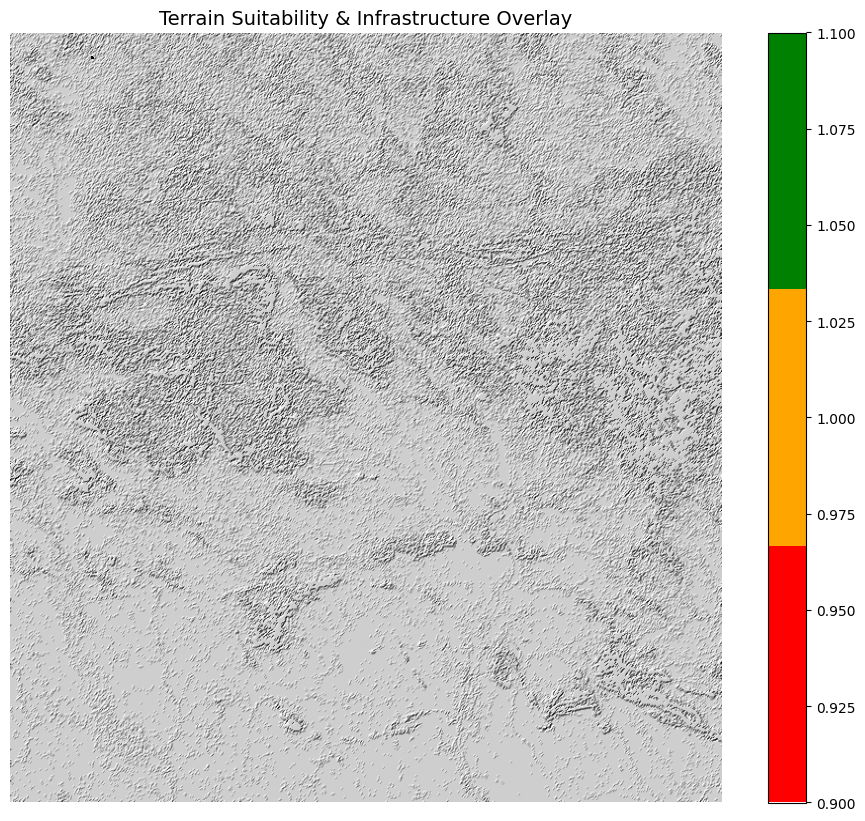

In [5]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.features import shapes
from matplotlib.colors import ListedColormap, LightSource

# --- Step 1: Load DEM ---
with rasterio.open("P5_PAN_CD_N22_000_E082_000_DEM_30m.tif") as src:
    elevation = src.read(1)
    transform = src.transform
    crs = src.crs

# ⭐ Fast preview mode
factor = 5
elevation = elevation[::factor, ::factor]
transform = transform * rasterio.Affine.scale(factor, factor)

# --- Step 2: Compute Slope ---
def compute_slope(elevation, pixel_size):
    dzdx = np.gradient(elevation, axis=1) / pixel_size
    dzdy = np.gradient(elevation, axis=0) / pixel_size
    slope = np.sqrt(dzdx**2 + dzdy**2)
    return np.degrees(np.arctan(slope))

slope = compute_slope(elevation, pixel_size=30 * factor)

# --- Step 3: Risk Classification ---
risk = np.zeros_like(slope, dtype=np.int16)
risk[slope < 2] = 1
risk[slope > 10] = 2
risk[(slope >= 2) & (slope <= 5)] = 3

# --- Step 4: Raster → Vector ---
mask = risk > 0

results = (
    {"properties": {"risk": int(v)}, "geometry": s}
    for s, v in shapes(risk, mask=mask, transform=transform)
)

gdf = gpd.GeoDataFrame.from_features(list(results), crs=crs)

# --- Step 5: Load GIS Infra ---
gis = gpd.read_file("slope_risk.geojson").to_crs(gdf.crs)

# --- Step 6: Create Hillshade (Professional Look) ---
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(elevation, vert_exag=1)

# --- Step 7: Professional Plot ---
fig, ax = plt.subplots(figsize=(12,10))

# Hillshade background
ax.imshow(hillshade, cmap="gray")

# Risk colors
risk_cmap = ListedColormap(["red", "orange", "green"])

gdf.plot(
    column="risk",
    cmap=risk_cmap,
    legend=True,
    alpha=0.5,
    ax=ax
)

# GIS infrastructure overlay
gis.boundary.plot(ax=ax, color="black", linewidth=0.7)

plt.title("Terrain Suitability & Infrastructure Overlay", fontsize=14)
plt.axis("off")
plt.show()


In [6]:
print(len(gdf))

1


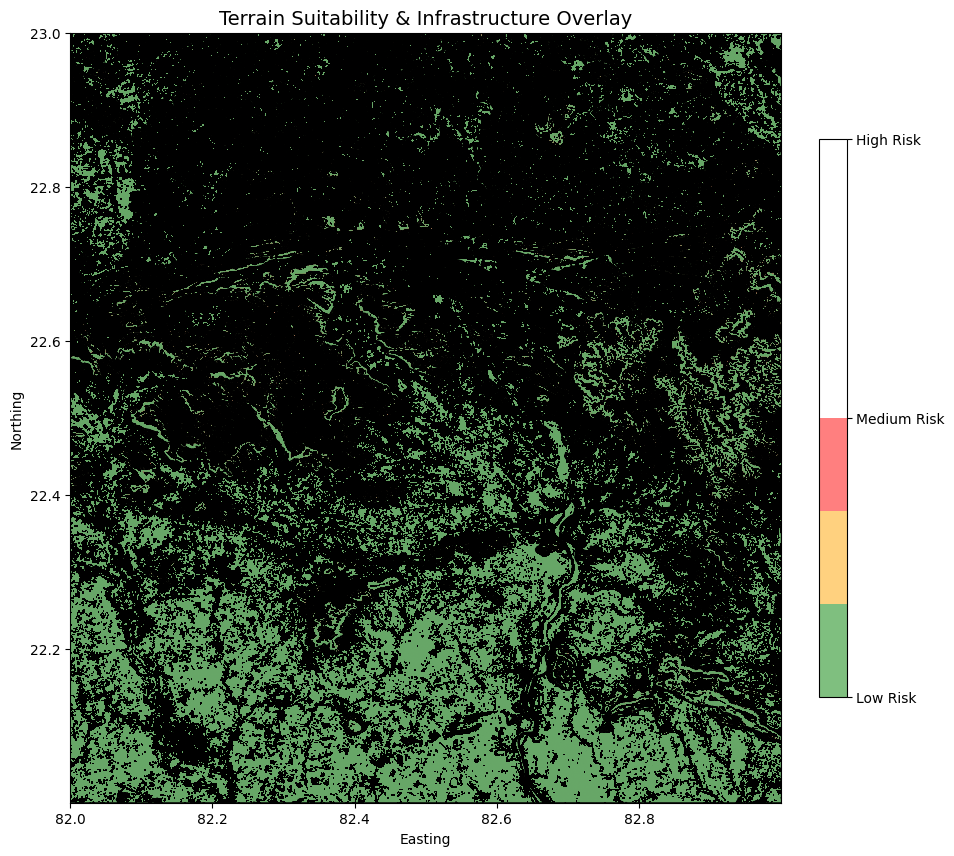

In [8]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import ListedColormap

# -------------------------
# 1. LOAD DEM  (YOUR FILE)
# -------------------------
dem_path = "P5_PAN_CD_N22_000_E082_000_DEM_30m.tif"

with rasterio.open(dem_path) as src:
    elevation = src.read(1)
    transform = src.transform
    crs = src.crs

# -------------------------
# 2. LOAD GIS LAYER (YOUR FILE)
# -------------------------
gis_path = "slope_risk.geojson"

gis = gpd.read_file(gis_path)

if gis.crs != crs:
    gis = gis.to_crs(crs)

# -------------------------
# 3. COMPUTE SLOPE (FAST)
# -------------------------
pixel_size = 30  # DEM resolution (meters)

dzdx = np.gradient(elevation, axis=1) / pixel_size
dzdy = np.gradient(elevation, axis=0) / pixel_size

slope = np.sqrt(dzdx**2 + dzdy**2)
slope_deg = np.degrees(np.arctan(slope))

# -------------------------
# 4. CREATE HILLSHADE
# -------------------------
azimuth = 315
altitude = 45

azimuth_rad = np.radians(azimuth)
altitude_rad = np.radians(altitude)

slope_rad = np.pi/2 - np.arctan(np.sqrt(dx*dx + dy*dy))
aspect_rad = np.arctan2(-dx, dy)

hillshade = (
    np.sin(altitude_rad) * np.sin(slope_rad) +
    np.cos(altitude_rad) * np.cos(slope_rad) *
    np.cos(azimuth_rad - aspect_rad)
)

hillshade = (hillshade - hillshade.min()) / (hillshade.max() - hillshade.min())

# -------------------------
# 5. CLASSIFY TERRAIN RISK
# -------------------------
risk = np.zeros_like(slope_deg)

risk[(slope_deg >= 0) & (slope_deg < 2)] = 1    # Water pooling / flood prone
risk[(slope_deg >= 2) & (slope_deg <= 10)] = 2  # Buildable terrain
risk[(slope_deg > 10)] = 3
# -------------------------
# 6. COLOR MAP
# -------------------------
risk_cmap = ListedColormap(["green", "orange", "red"])

# -------------------------
# 7. EXTENT FOR GEO PLOT
# -------------------------
rows, cols = elevation.shape

extent = [
    transform[2],
    transform[2] + transform[0] * cols,
    transform[5] + transform[4] * rows,
    transform[5]
]

# -------------------------
# 8. PLOT PROFESSIONAL MAP
# -------------------------
fig, ax = plt.subplots(figsize=(12,10))

# Hillshade background
ax.imshow(hillshade, cmap="gray", extent=extent)

# Risk overlay
risk_masked = np.ma.masked_where(risk == 0, risk)

im = ax.imshow(
    risk_masked,
    cmap=risk_cmap,
    alpha=0.5,
    extent=extent
)

# GIS overlay
gis.boundary.plot(ax=ax, color="black", linewidth=0.7)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_ticks([1,2,3])
cbar.set_ticklabels(["Low Risk","Medium Risk","High Risk"])

plt.title("Terrain Suitability & Infrastructure Overlay", fontsize=14)
plt.xlabel("Easting")
plt.ylabel("Northing")

plt.show()


Calculating flow direction...
Calculating flow accumulation...


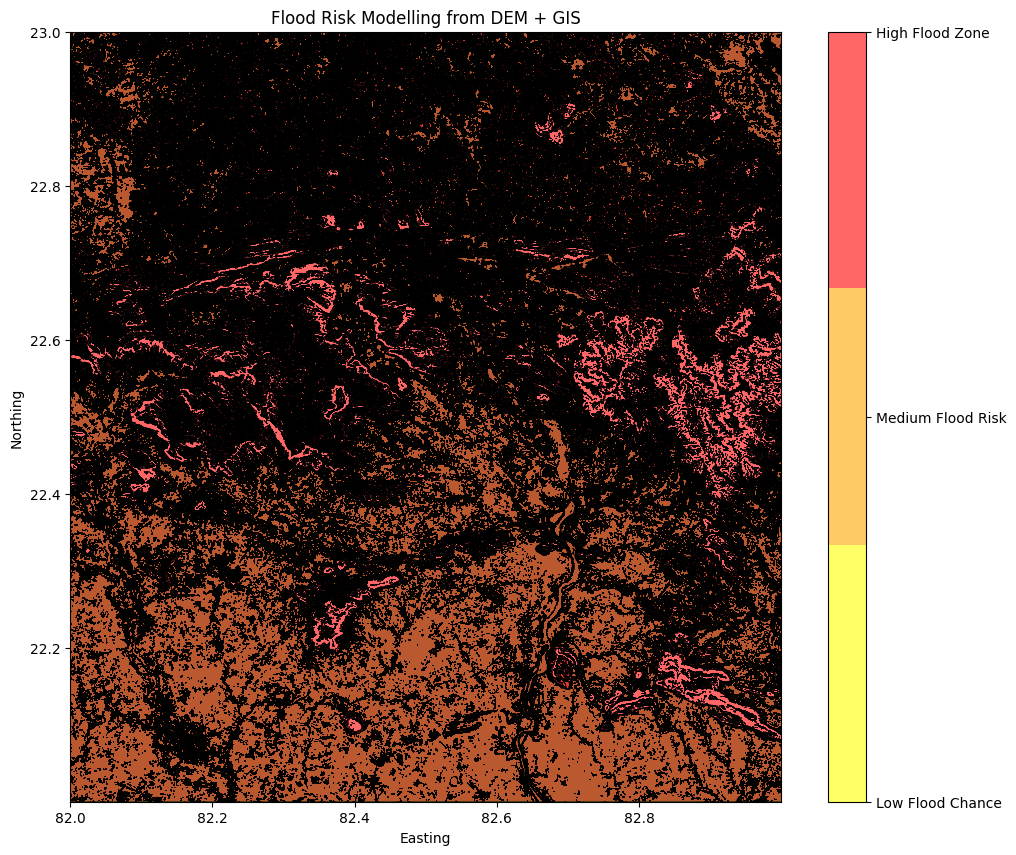

In [9]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import convolve

# -------------------------
# 1. LOAD DEM
# -------------------------
dem_path = "P5_PAN_CD_N22_000_E082_000_DEM_30m.tif"
gis_path = "slope_risk.geojson"

with rasterio.open(dem_path) as src:
    elevation = src.read(1).astype(float)
    transform = src.transform
    crs = src.crs

rows, cols = elevation.shape

# -------------------------
# 2. COMPUTE SLOPE
# -------------------------
pixel_size = 30

dzdx = np.gradient(elevation, axis=1) / pixel_size
dzdy = np.gradient(elevation, axis=0) / pixel_size

slope = np.sqrt(dzdx**2 + dzdy**2)
slope_deg = np.degrees(np.arctan(slope))

# -------------------------
# 3. FLOW DIRECTION (D8 method)
# -------------------------

def flow_direction(dem):

    kernel = np.array([
        [32, 64, 128],
        [16,  0,   1],
        [8,   4,   2]
    ])

    flow_dir = np.zeros_like(dem)

    for i in range(1, dem.shape[0]-1):
        for j in range(1, dem.shape[1]-1):

            window = dem[i-1:i+2, j-1:j+2]
            diff = window - dem[i, j]

            if np.min(diff) < 0:
                flow_dir[i,j] = kernel.flatten()[np.argmin(diff)]

    return flow_dir

print("Calculating flow direction...")
flow_dir = flow_direction(elevation)

# -------------------------
# 4. FLOW ACCUMULATION
# -------------------------

def flow_accumulation(flow_dir):

    acc = np.ones_like(flow_dir)

    for _ in range(30):  # iterations approximate water flow
        acc += convolve(acc, np.ones((3,3)), mode='constant')

    return acc

print("Calculating flow accumulation...")
flow_acc = flow_accumulation(flow_dir)

# Normalize
flow_acc = flow_acc / np.max(flow_acc)

# -------------------------
# 5. FLOOD RISK CLASSIFICATION
# -------------------------

flood_risk = np.zeros_like(flow_acc)

flood_risk[flow_acc > 0.6] = 3     # High flood zone
flood_risk[(flow_acc > 0.3) & (flow_acc <= 0.6)] = 2
flood_risk[(flow_acc > 0.1) & (flow_acc <= 0.3)] = 1

# -------------------------
# 6. LOAD GIS INFRA
# -------------------------
gis = gpd.read_file(gis_path)
gis = gis.to_crs(crs)

# -------------------------
# 7. VISUALIZATION
# -------------------------

extent = [
    transform[2],
    transform[2] + transform[0]*cols,
    transform[5] + transform[4]*rows,
    transform[5]
]

# Professional flood color map
flood_cmap = ListedColormap([
    "yellow",    # Low flood chance
    "orange",    # Medium
    "red"        # High flood zone
])

fig, ax = plt.subplots(figsize=(12,10))

# Terrain background
ax.imshow(elevation, cmap="terrain", extent=extent)

# Flood overlay
mask = np.ma.masked_where(flood_risk == 0, flood_risk)

img = ax.imshow(
    mask,
    cmap=flood_cmap,
    alpha=0.6,
    extent=extent
)

# Infrastructure overlay
gis.boundary.plot(ax=ax, color="black", linewidth=0.5)

cbar = plt.colorbar(img, ax=ax)
cbar.set_ticks([1,2,3])
cbar.set_ticklabels([
    "Low Flood Chance",
    "Medium Flood Risk",
    "High Flood Zone"
])

plt.title("Flood Risk Modelling from DEM + GIS")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()


Calculating flow direction...
Calculating flow accumulation...


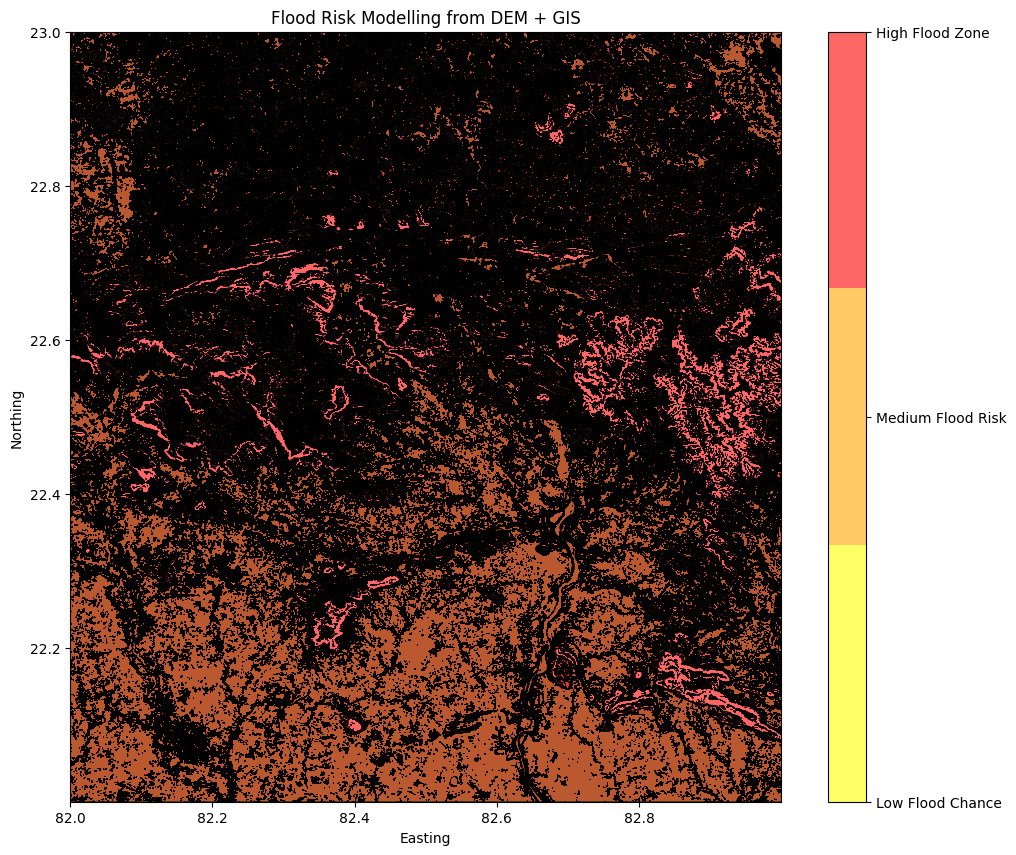

In [10]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import convolve

# -------------------------
# 1. LOAD DEM
# -------------------------
dem_path = "P5_PAN_CD_N22_000_E082_000_DEM_30m.tif"
gis_path = "slope_risk.geojson"

with rasterio.open(dem_path) as src:
    elevation = src.read(1).astype(float)
    transform = src.transform
    crs = src.crs

rows, cols = elevation.shape

# -------------------------
# 2. COMPUTE SLOPE
# -------------------------
pixel_size = 30

dzdx = np.gradient(elevation, axis=1) / pixel_size
dzdy = np.gradient(elevation, axis=0) / pixel_size

slope = np.sqrt(dzdx**2 + dzdy**2)
slope_deg = np.degrees(np.arctan(slope))

# -------------------------
# 3. FLOW DIRECTION (D8 method)
# -------------------------

def flow_direction(dem):

    kernel = np.array([
        [32, 64, 128],
        [16,  0,   1],
        [8,   4,   2]
    ])

    flow_dir = np.zeros_like(dem)

    for i in range(1, dem.shape[0]-1):
        for j in range(1, dem.shape[1]-1):

            window = dem[i-1:i+2, j-1:j+2]
            diff = window - dem[i, j]

            if np.min(diff) < 0:
                flow_dir[i,j] = kernel.flatten()[np.argmin(diff)]

    return flow_dir

print("Calculating flow direction...")
flow_dir = flow_direction(elevation)

# -------------------------
# 4. FLOW ACCUMULATION
# -------------------------

def flow_accumulation(flow_dir):

    acc = np.ones_like(flow_dir)

    for _ in range(30):  # iterations approximate water flow
        acc += convolve(acc, np.ones((3,3)), mode='constant')

    return acc

print("Calculating flow accumulation...")
flow_acc = flow_accumulation(flow_dir)

# Normalize
from scipy.ndimage import gaussian_filter

# Normalize
flow_acc = flow_acc / np.max(flow_acc)

# Smooth accumulation (removes pixel noise)
flow_acc = gaussian_filter(flow_acc, sigma=2)


# -------------------------
# 5. FLOOD RISK CLASSIFICATION
# -------------------------

flood_risk = np.zeros_like(flow_acc)

flood_risk[flow_acc > 0.6] = 3     # High flood zone
flood_risk[(flow_acc > 0.3) & (flow_acc <= 0.6)] = 2
flood_risk[(flow_acc > 0.1) & (flow_acc <= 0.3)] = 1

# -------------------------
# 6. LOAD GIS INFRA
# -------------------------
gis = gpd.read_file(gis_path)
gis = gis.to_crs(crs)

# -------------------------
# 7. VISUALIZATION
# -------------------------

extent = [
    transform[2],
    transform[2] + transform[0]*cols,
    transform[5] + transform[4]*rows,
    transform[5]
]

# Professional flood color map
flood_cmap = ListedColormap([
    "yellow",    # Low flood chance
    "orange",    # Medium
    "red"        # High flood zone
])

fig, ax = plt.subplots(figsize=(12,10))

# Terrain background
ax.imshow(elevation, cmap="terrain", extent=extent)

# Flood overlay
mask = np.ma.masked_where(flood_risk == 0, flood_risk)

img = ax.imshow(
    mask,
    cmap=flood_cmap,
    alpha=0.6,
    extent=extent
)

# Infrastructure overlay
gis.boundary.plot(ax=ax, color="black", linewidth=0.5)

cbar = plt.colorbar(img, ax=ax)
cbar.set_ticks([1,2,3])
cbar.set_ticklabels([
    "Low Flood Chance",
    "Medium Flood Risk",
    "High Flood Zone"
])

plt.title("Flood Risk Modelling from DEM + GIS")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()
